In [1]:
from vmc_ising import (
    output_dir,
    get_config,
    get_lattice,
    default_config,
    get_network,
    get_system,
    reconstruct_signs,
    find_sign_overlap,
)
from misc_utils import read_jsonl_to_df, keep_serializable, concat_columns, column_to
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from nqs_playground_helpers import safe_exp
import torch
from pathlib import Path
from collections.abc import Iterable
import jsonlines
import pandas as pd
from misc_utils import make_unpacked_configurations




from fourier_paper_reproduction import (
    accuracy as thresholded_accuracy,
    get_ipr,
    how_many_terms_to_achieve,
    how_many_terms_to_achieve_relative_weight,
    rel_fourier_weight_in_largest_terms,
    sign_overlap,
)
from fourier_supervised_cleanroom import (
    amplitude_median_bin_signal as thresholded_amplitude_median_bin_signal,
    amplitude_prob_median_bin_signal,
    amplitude_signal,
    fit_fourier_series,
    ground_state_signal,
    hadamard_transform,
    keep_largest_n,
    sign_signal as thresholded_sign_signal,
)
from heisenberg_hamiltonians import SpinSystem
import numpy.typing as npt
from vmc_ising import get_energy
from vmc_amplitude import get_csr_hamiltonian
from scipy.sparse import diags
from scipy.sparse import coo_matrix
from nqs_playground_helpers import forward_with_batches
from spin_lattices import AllToAllLattice
from heisenberg_hamiltonians import HeisenbergJ1J2
import lattice_symmetries as ls
from scipy.sparse import csr_matrix

Running dilated_nns_xors.py


In [2]:
task_id = 51
df = read_jsonl_to_df(output_dir.glob(f"{task_id}/results.jsonl")).fillna(
    keep_serializable(default_config)
)

In [3]:
config = get_config(task_id)
system = get_system(config)
system.get_eigenstates(1)
log_prob_fn = get_network(config, get_system(config))
hamiltonian_matrix = get_csr_hamiltonian(system)

all_to_all_lattice = AllToAllLattice(system.lattice)
full_spin_system = HeisenbergJ1J2(
    lattice=all_to_all_lattice,
    use_symmetries=system.use_symmetries,
    spin_inversion=system.spin_inversion,
)
full_spin_matrix = get_csr_hamiltonian(full_spin_system)

2024-03-19 19:48:05.776 | DEBUG    | heisenberg_hamiltonians:__init__:526 - number_spins=24
2024-03-19 19:48:05.776 | DEBUG    | heisenberg_hamiltonians:__init__:528 - Setting hamming_weight to half
2024-03-19 19:48:05.777 | DEBUG    | heisenberg_hamiltonians:__init__:541 - Symmetry group contains 0 elements
2024-03-19 19:48:05.778 | DEBUG    | heisenberg_hamiltonians:__init__:542 - Constructing basis
2024-03-19 19:48:05.843 | DEBUG    | heisenberg_hamiltonians:__init__:550 - Hilbert space dimension is 2704156
2024-03-19 19:48:05.852 | DEBUG    | heisenberg_hamiltonians:_find_cached_eigenstate:77 - Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x4-1.0-1.0-False-None-10.pickle
2024-03-19 19:48:06.022 | DEBUG    | heisenberg_hamiltonians:get_eigenstates:129 - Ground state energy is -43.0395889923
2024-03-19 19:48:06.030 | DEBUG    | heisenberg_hamiltonians:__init__:526 - number_spins=24
2024-03-19 19:48:06.030 | DEBUG    | heisenberg_hami

In [4]:
steps = df.query("task_id == @task_id and signs_updated")["step"].to_numpy()
data = []
for step in (steps - 1)[:1]:
    print(step)
    true_signs = np.sign(system.get_ground_state())
    random_signs = np.random.choice([-1, 1], size=true_signs.shape)
    reconstructed_signs = torch.load(
        output_dir / f"{task_id}/reconstructed_signs_{step}.pt"
    )
    predicted_amplitudes = torch.load(
        output_dir / f"{task_id}/amplitudes_all_states_{step}.pt",
        map_location=torch.device("cpu"),
    )
    log_prob_fn.load_state_dict(
        torch.load(
            output_dir / f"{task_id}/log_prob_fn_{step}.pt",
            map_location=torch.device("cpu"),
        )
    )
    data.append(
        dict(
            sign_overlap=find_sign_overlap(system, reconstructed_signs),
            energy_true_signs=get_energy(
                true_signs, system.basis, system.hamiltonian, log_prob_fn
            ),
            energy_reconstructed_signs=get_energy(
                reconstructed_signs, system.basis, system.hamiltonian, log_prob_fn
            ),
            energy_random_signs=get_energy(
                random_signs, system.basis, system.hamiltonian, log_prob_fn
            ),
            full_spin_true_signs=get_energy(
                true_signs,
                full_spin_system.basis,
                full_spin_system.hamiltonian,
                log_prob_fn,
            ),
            full_spin_reconstructed_signs=get_energy(
                reconstructed_signs,
                full_spin_system.basis,
                full_spin_system.hamiltonian,
                log_prob_fn,
            ),
            full_spin_random_signs=get_energy(
                random_signs,
                full_spin_system.basis,
                full_spin_system.hamiltonian,
                log_prob_fn,
            ),
        )
    )
df2 = pd.DataFrame(data)

82


In [5]:
df2

,sign_overlap,energy_true_signs,energy_reconstructed_signs,energy_random_signs,full_spin_true_signs,full_spin_reconstructed_signs,full_spin_random_signs
0,0.000696,-33.683658,-33.944493,-13.992153,13.353419,15.213561,48.015747


In [22]:
def symmetry_overlap(system, sign_structure, symmetry):
    return (
        system.get_ground_state() ** 2 * sign_structure
        * sign_structure[
            system.basis.index(
                system.make_packed_configurations(
                    system.make_unpacked_configurations(system.basis.states)[
                        :, symmetry
                    ]
                )
            )
        ]
    ).sum()

In [26]:
symmetries = system.lattice.get_automorphisms()
print("i\ttrue\treconstructed")
for i, symmetry in enumerate(symmetries):
    print(
        f"{i}\t{symmetry_overlap(system, true_signs, symmetry):.2f}"
        f"\t{symmetry_overlap(system, reconstructed_signs, symmetry):.2f}"
    )

i	true	reconstructed
0	1.00	1.00
1	-1.00	-0.02
2	-1.00	-0.02
3	1.00	0.97
4	-1.00	0.98
5	1.00	-0.02
6	1.00	-0.02
7	-1.00	0.96
8	1.00	0.98
9	-1.00	-0.02
10	-1.00	-0.02
11	1.00	0.97
12	-1.00	0.98
13	1.00	-0.02
14	1.00	-0.02
15	-1.00	0.96


<Axes: xlabel='emb_x', ylabel='emb_y'>

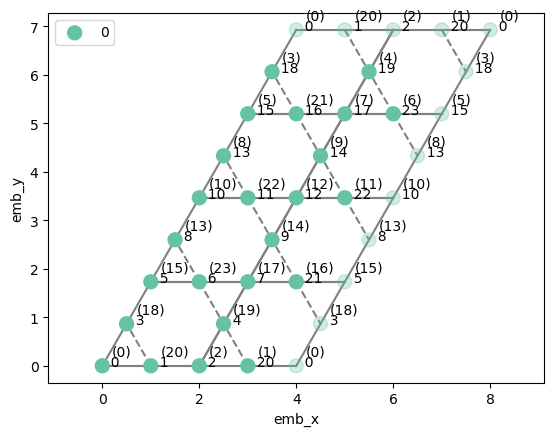

In [27]:
system.lattice.plot(permutation=system.lattice.get_automorphisms()[1])

In [11]:
data = []
for s in np.linspace(0, 1, 11):
    energy_full_spin_true_signs=get_energy(
        true_signs,
        system.basis,
        (1 - s) * system.hamiltonian + s * full_spin_system.hamiltonian,
        log_prob_fn,
    )
    energy_full_spin_reconstructed_signs=get_energy(
        reconstructed_signs,
        system.basis,
        (1 - s) * system.hamiltonian + s * full_spin_system.hamiltonian,
        log_prob_fn,
    )
    data.append(
        dict(
            s=s,
            energy_full_spin_true_signs=energy_full_spin_true_signs,
            energy_full_spin_reconstructed_signs=energy_full_spin_reconstructed_signs,
        )
    )
df3 = pd.DataFrame(data)

In [17]:
full_spin_matrix = get_csr_hamiltonian(full_spin_system)

In [15]:
df3.set_index("s").assign(
    delta=lambda df: df["energy_full_spin_true_signs"]
    - df["energy_full_spin_reconstructed_signs"]
)["delta"]

s
0.0    0.260835
0.1    0.048737
0.2   -0.163361
0.3   -0.375458
0.4   -0.587556
0.5   -0.799654
0.6   -1.011752
0.7   -1.223849
0.8   -1.435947
0.9   -1.648045
1.0   -1.860143
Name: delta, dtype: float64

<Axes: >

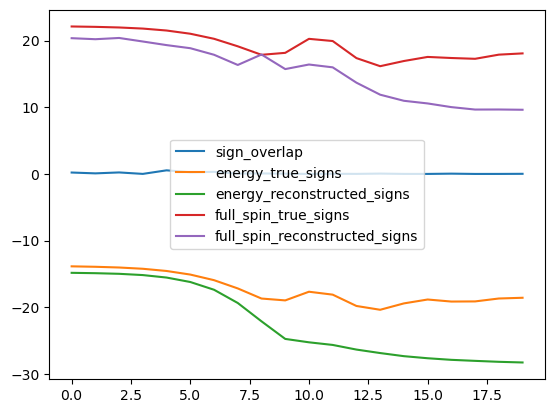

In [48]:
df.query(f'task_id == @task_id and step == {step + 1}').iloc[0]

config_n_samples                                                                                   10000
config_lr                                                                                          0.001
config_batch_size                                                                                  10000
config_weight_decay                                                                                    0
config_max_iter                                                                                    15000
config_lattice                                                                                 kagome2x3
config_J2                                                                                              1
config_use_symmetries                                                                              False
config_spin_inversion                                                                               None
config_eval_set_max_size                               

In [50]:
(true_signs * reconstructed_signs).mean()

0.049526943644590704

In [44]:
get_energy(reconstructed_signs, system, log_prob_fn)

-15.171146216155986

In [45]:
get_energy(true_signs, full_spin_system, log_prob_fn)

21.810223407706587

In [46]:
get_energy(reconstructed_signs, full_spin_system, log_prob_fn)

19.870542843713014

In [13]:
amplitudes_diag = diags(predicted_amplitudes)

In [14]:
(predicted_amplitudes > 0).all()

True

In [15]:
ising_hamiltonian = amplitudes_diag @ (hamiltonian_matrix)  @ amplitudes_diag
ising_full_spin =  amplitudes_diag @ (full_spin_matrix)  @ amplitudes_diag

In [16]:
ising_hamiltonian.diagonal().sum()

-2.1277299959199265

In [22]:
new_ising_hamiltonian = ising_hamiltonian - diags(ising_hamiltonian.diagonal())

In [26]:
(new_ising_hamiltonian.data > 0).all()

True

In [32]:
new_ising_hamiltonian_coo = new_ising_hamiltonian.tocoo()

In [27]:
sort_order = np.argsort(new_ising_hamiltonian.data)

In [35]:
(np.diff(new_ising_hamiltonian_coo.data[sort_order]) >= 0).all()

True

In [75]:
n_elements = 210
i_s = new_ising_hamiltonian_coo.row[sort_order][-n_elements:]
j_s = new_ising_hamiltonian_coo.col[sort_order][-n_elements:]

In [64]:
i_s_full = new_ising_hamiltonian_coo.row[sort_order]
j_s_full = new_ising_hamiltonian_coo.col[sort_order]

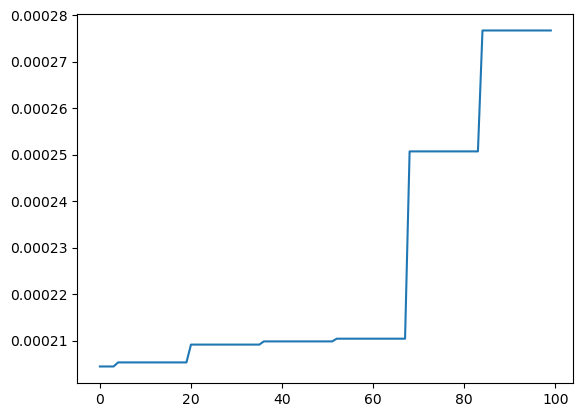

In [31]:
plt.plot(new_ising_hamiltonian.data[sort_order[-100:]])

In [38]:
greedy_signs = torch.load(output_dir / f"{task_id}/reconstructed_signs_{step}.pt")

In [66]:
greedy_contrib = greedy_signs[i_s_full] * new_ising_hamiltonian_coo.data[sort_order] * greedy_signs[j_s_full]
true_contrib = true_signs[i_s_full] * new_ising_hamiltonian_coo.data[sort_order] * true_signs[j_s_full]

In [102]:
for eps in np.linspace(0, 10, 11):
    contribution_with_full_spin = (greedy_signs[i_s_full]
        * (ising_hamiltonian + eps * ising_full_spin).data[sort_order]
        * greedy_signs[j_s_full])
    print(eps, ((contribution_with_full_spin > 0) == (true_contrib > 0))[-10000:].mean())

0.0 0.6972
1.0 0.703
2.0 0.703
3.0 0.703


KeyboardInterrupt: 

In [74]:
np.where(((greedy_contrib > 0) & (true_contrib < 0))[::-1])

(array([     208,      209,      210, ..., 67721416, 67721417, 67721419]),)

In [83]:
i_s[-209], j_s[-209]

(1589247, 1590753)

In [87]:
greedy_contrib[-209]

0.00018715608700585473

In [85]:
true_contrib[-209]

-0.00018715608700585473

In [80]:
(greedy_contrib < 0).sum()

44181060

In [81]:
(true_contrib < 0).sum()

43662768

In [77]:
((greedy_contrib > 0) & (true_contrib < 0))

array([False, False, False, ..., False, False, False])

In [61]:
list(true_signs[i_s] * new_ising_hamiltonian_coo.data[sort_order[-n_elements:]] * true_signs[j_s])

[0.00020986461812958282,
 0.00020986461812958282,
 -0.00021045085659703207,
 0.00021045085659703207,
 0.00021045085659703207,
 0.00021045085659703207,
 -0.00021045085659703207,
 0.00021045085659703207,
 -0.00021045085659703207,
 -0.00021045085659703207,
 -0.00021045085659703207,
 0.00021045085659703207,
 0.00021045085659703207,
 -0.00021045085659703207,
 -0.00021045085659703207,
 0.00021045085659703207,
 -0.00021045085659703207,
 0.00021045085659703207,
 -0.00025073407637986843,
 0.00025073407637986843,
 -0.00025073407637986843,
 0.00025073407637986843,
 0.00025073407637986843,
 0.00025073407637986843,
 -0.00025073407637986843,
 -0.00025073407637986843,
 0.00025073407637986843,
 0.00025073407637986843,
 -0.00025073407637986843,
 -0.00025073407637986843,
 -0.00025073407637986843,
 0.00025073407637986843,
 -0.00025073407637986843,
 0.00025073407637986843,
 0.0002767400663572332,
 0.0002767400663572332,
 -0.0002767400663572332,
 -0.0002767400663572332,
 0.0002767400663572332,
 -0.00027674

In [27]:
side = int(np.sqrt(true_signs.shape[0])) // 4

In [23]:
(true_signs == 0).mean()

0.0

In [115]:
good_greedy_signs = torch.load(output_dir / f"53/reconstructed_signs_341.pt")

In [52]:
def sign_signal_factory(system: SpinSystem, signs: npt.NDArray):
    def wrapper(s: npt.NDArray) -> npt.NDArray:
        return signs[system.basis.index(s)]
    return wrapper

In [53]:
true_signs_fn = sign_signal_factory(system, true_signs)
greedy_signs_fn = sign_signal_factory(system, greedy_signs)

In [55]:
def get_series_coeff(system, signal_fn):
    return fit_fourier_series(
            system.canonical_basis.states,
            signal_fn=signal_fn,
            n_bits=system.number_spins,
        )

In [56]:
true_signs_coeff = get_series_coeff(system, true_signs_fn)
greedy_signs_coeff = get_series_coeff(system, greedy_signs_fn)

In [59]:
how_many_terms_to_achieve_relative_weight(true_signs_coeff, 0.5)

267606

In [60]:
how_many_terms_to_achieve_relative_weight(greedy_signs_coeff, 0.5)

675992

In [74]:
from misc_utils import make_unpacked_configurations, make_unpacked_configurations_numpy


def walking_bits(n, k):
    seq = [0] * n
    output = []
    def walk(n, k, dir, pos):
        for i in range(1, n - k + 2):
            seq[pos] = 1
            if k > 1:
                walk(
                    n - i,
                    k - 1,
                    dir if i % 2 else -dir,
                    pos + dir * (1 if i % 2 else n - i),
                )
            else:
                output.append(sum(2 ** i for i, x in enumerate(seq) if x))
            seq[pos] = 0
            pos += dir

    walk(n, k, 1, 0)
    return output


states_walking = np.array(walking_bits(system.number_spins, system.number_spins // 2))

In [81]:
states_walking = np.array(states_walking)

In [50]:
reconstructed_signs_list = []
for step in range(0, 15000, 100):
    log_prob_fn.load_state_dict(
        torch.load(
            output_dir / f"{task_id}/log_prob_fn_{step}.pt",
            map_location=torch.device("cpu"),
        )
    )
    reconstructed_signs_list.append(
        reconstruct_signs(
            system,
            log_prob_fn,
            number_sweeps=config["sign_reconstruction.number_sweeps"],
            how=config["sign_reconstruction.method"],
            repetitions=config["sign_reconstruction.repetitions"],
        )
    )

In [51]:
reconstructed_signs_list = reconstructed_signs

In [52]:
ising_energy = []
previous_reconstructed_signs = None
for step, reconstructed_signs in zip(range(0, 15000, 100), reconstructed_signs_list):
    log_prob_fn.load_state_dict(
        torch.load(
            output_dir / f"{task_id}/log_prob_fn_{step}.pt",
            map_location=torch.device("cpu"),
        )
    )
    if previous_reconstructed_signs is not None:
        sign_overlap_incremental = (
            reconstructed_signs
            * previous_reconstructed_signs
            * system.get_ground_state() ** 2
        ).sum()
    else:
        sign_overlap_incremental = None
    sign_overlap_with_true = find_sign_overlap(system, reconstructed_signs)

    previous_reconstructed_signs = reconstructed_signs
    ising_energy.append(
        dict(
            ising_energy_reconstructed_signs=get_energy(
                reconstructed_signs, system, log_prob_fn
            ),
            ising_energy_true_signs=get_energy(true_signs, system, log_prob_fn),
            step=step,
            sign_overlap_incremental=sign_overlap_incremental,
            sign_overlap_with_true=sign_overlap_with_true,
        )
    )
    # system.hamiltonian @ wavefunction

<Axes: xlabel='step'>

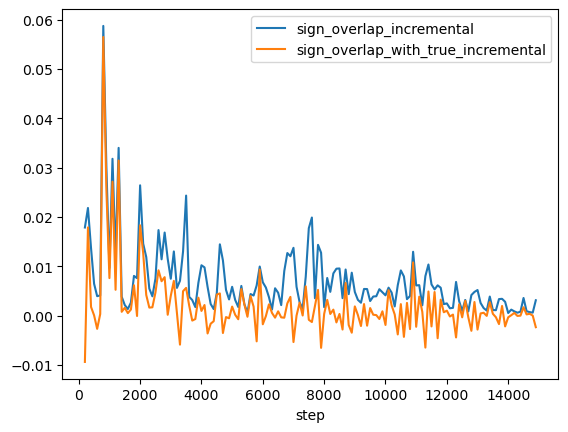

In [58]:
pd.DataFrame(ising_energy).assign(
    delta=lambda df: df["ising_energy_reconstructed_signs"]
    - df["ising_energy_true_signs"],
    sign_overlap_incremental=lambda df: 1 - df["sign_overlap_incremental"].abs(),
    sign_overlap_with_true_incremental=lambda df: df["sign_overlap_with_true"].diff()
).set_index("step").iloc[2:][["sign_overlap_incremental", "sign_overlap_with_true_incremental"]].plot()

In [63]:
pd.DataFrame(ising_energy).assign(
    delta=lambda df: df["ising_energy_reconstructed_signs"]
    - df["ising_energy_true_signs"],
    sign_overlap_incremental=lambda df: 1 - df["sign_overlap_incremental"].abs(),
    sign_overlap_with_true_incremental=lambda df: df["sign_overlap_with_true"].diff()
).query("step > 10000")['sign_overlap_incremental'].mean()

0.0036988500363071314

In [60]:
pd.DataFrame(ising_energy).assign(
    delta=lambda df: df["ising_energy_reconstructed_signs"]
    - df["ising_energy_true_signs"],
    sign_overlap_incremental=lambda df: 1 - df["sign_overlap_incremental"].abs(),
    sign_overlap_with_true_incremental=lambda df: df["sign_overlap_with_true"].diff()
)['sign_overlap_with_true']

0      0.017012
1      0.646373
2      0.636964
3      0.654824
4      0.656566
         ...   
145    0.950284
146    0.950510
147    0.950858
148    0.950843
149    0.948475
Name: sign_overlap_with_true, Length: 150, dtype: float64